# EEG-Based Alzheimer's Disease Classification

### Logistic Regression — AD vs Cognitively Normal

This notebook applies Logistic Regression to the subject-level EEG spectral features generated from the complete OpenNeuro `ds004504` dataset.

**Classification:** Alzheimer's disease (AD) vs Cognitively normal (CN)  
**Subjects:** 65  
**Features:** Delta, Theta, Alpha, Beta, Gamma  
**Model:** Logistic Regression

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("../data/all_subjects_features.csv")

In [3]:
df.head()

,subject,group,age,MMSE,delta,theta,alpha,beta,gamma
0,sub-001,A,57,16,0.345179,0.328017,0.102048,0.129601,0.095154
1,sub-002,A,78,22,0.143655,0.154829,0.464910,0.190827,0.045779
2,sub-003,A,70,14,0.222562,0.231461,0.476515,0.053760,0.015702
3,sub-004,A,67,20,0.420912,0.277658,0.071022,0.123877,0.106531
4,sub-005,A,70,22,0.349276,0.211557,0.170443,0.193253,0.075471


In [4]:
df = df[df["group"].isin(["A","C"])]

In [6]:
df["group"].value_counts()

group
A    36
C    29
Name: count, dtype: int64

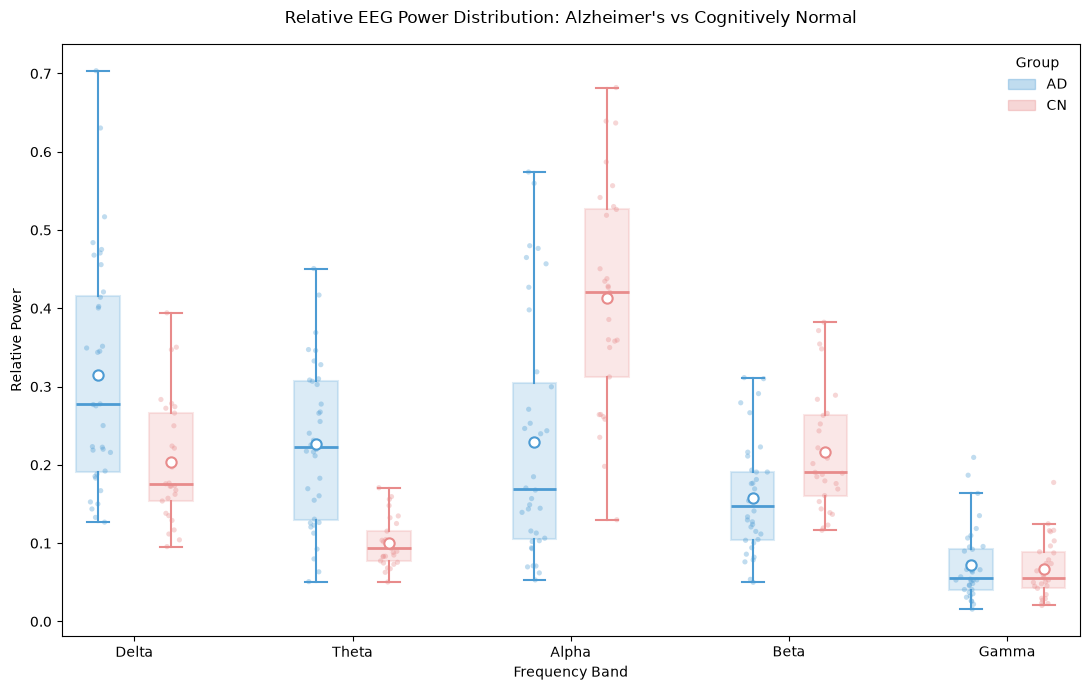

In [67]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import numpy as np

features = ["delta", "theta", "alpha", "beta", "gamma"]

AD_data = []
CN_data = []

for feature in features:
    AD_data.append(df[df["group"] == "A"][feature])
    CN_data.append(df[df["group"] == "C"][feature])

plt.figure(figsize=(11, 7))

positions_AD = [1, 4, 7, 10, 13]
positions_CN = [2, 5, 8, 11, 14]

AD_color = "#4C9BD3"
CN_color = "#E88B8B"

plt.boxplot(
    AD_data,
    positions=positions_AD,
    widths=0.6,
    patch_artist=True,
    showfliers=False,
    boxprops=dict(
        facecolor=AD_color,
        alpha=0.20,
        edgecolor=AD_color,
        linewidth=1.5
    ),
    whiskerprops=dict(
        color=AD_color,
        linewidth=1.5
    ),
    capprops=dict(
        color=AD_color,
        linewidth=1.5
    ),
    medianprops=dict(
        color=AD_color,
        linewidth=2
    )
)

plt.boxplot(
    CN_data,
    positions=positions_CN,
    widths=0.6,
    patch_artist=True,
    showfliers=False,
    boxprops=dict(
        facecolor=CN_color,
        alpha=0.20,
        edgecolor=CN_color,
        linewidth=1.5
    ),
    whiskerprops=dict(
        color=CN_color,
        linewidth=1.5
    ),
    capprops=dict(
        color=CN_color,
        linewidth=1.5
    ),
    medianprops=dict(
        color=CN_color,
        linewidth=2
    )
)

rng = np.random.default_rng(42)

for i in range(len(features)):

    AD_jitter = rng.normal(
        positions_AD[i],
        0.08,
        len(AD_data[i])
    )

    CN_jitter = rng.normal(
        positions_CN[i],
        0.08,
        len(CN_data[i])
    )

    plt.scatter(
        AD_jitter,
        AD_data[i],
        s=14,
        color=AD_color,
        alpha=0.35,
        edgecolors="none"
    )

    plt.scatter(
        CN_jitter,
        CN_data[i],
        s=14,
        color=CN_color,
        alpha=0.35,
        edgecolors="none"
    )

    AD_mean = AD_data[i].mean()
    CN_mean = CN_data[i].mean()

    plt.scatter(
        positions_AD[i],
        AD_mean,
        s=55,
        facecolors="white",
        edgecolors=AD_color,
        linewidths=1.5,
        zorder=5
    )

    plt.scatter(
        positions_CN[i],
        CN_mean,
        s=55,
        facecolors="white",
        edgecolors=CN_color,
        linewidths=1.5,
        zorder=5
    )

plt.xticks(
    [1.5, 4.5, 7.5, 10.5, 13.5],
    ["Delta", "Theta", "Alpha", "Beta", "Gamma"]
)

plt.xlabel("Frequency Band")
plt.ylabel("Relative Power")

plt.title(
    "Relative EEG Power Distribution: Alzheimer's vs Cognitively Normal",
    pad=15
)

AD_legend = Patch(
    facecolor=AD_color,
    alpha=0.35,
    edgecolor=AD_color,
    label="AD"
)

CN_legend = Patch(
    facecolor=CN_color,
    alpha=0.35,
    edgecolor=CN_color,
    label="CN"
)

plt.legend(
    handles=[AD_legend, CN_legend],
    title="Group",
    frameon=False
)

plt.grid(False)

plt.tight_layout()
plt.show()

In [7]:
X = df[
    ["delta", "theta", "alpha", "beta", "gamma"]
    ]

In [8]:
X.head()

,delta,theta,alpha,beta,gamma
0,0.345179,0.328017,0.102048,0.129601,0.095154
1,0.143655,0.154829,0.464910,0.190827,0.045779
2,0.222562,0.231461,0.476515,0.053760,0.015702
3,0.420912,0.277658,0.071022,0.123877,0.106531
4,0.349276,0.211557,0.170443,0.193253,0.075471


In [9]:
y = df["group"]
y.head()

0    A
1    A
2    A
3    A
4    A
Name: group, dtype: str

In [10]:
print(X.shape)
print(y.shape)

(65, 5)
(65,)


In [11]:
from sklearn.model_selection import train_test_split

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [13]:
print(X_train.shape)
print(X_test.shape)

(52, 5)
(13, 5)


In [15]:
from sklearn.preprocessing import StandardScaler

In [16]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [18]:
from sklearn.linear_model import LogisticRegression

In [19]:
model = LogisticRegression()

In [20]:
model.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following

In [21]:
y_pred = model.predict(X_test_scaled)

In [22]:
print(y_pred)

['A' 'C' 'C' 'C' 'C' 'A' 'C' 'A' 'A' 'C' 'A' 'C' 'C']


In [23]:
from sklearn.metrics import accuracy_score

In [24]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.8461538461538461


In [26]:
print("Actual:", y_test.to_numpy())
print("Predicted:", y_pred)

Actual: ['A' 'C' 'C' 'A' 'C' 'A' 'C' 'A' 'A' 'C' 'A' 'C' 'A']
Predicted: ['A' 'C' 'C' 'C' 'C' 'A' 'C' 'A' 'A' 'C' 'A' 'C' 'C']


In [27]:
from sklearn.metrics import confusion_matrix

In [28]:
cm = confusion_matrix(
    y_test,
    y_pred,
    labels=["A", "C"]
)

print(cm)

[[5 2]
 [0 6]]


In [29]:
from sklearn.metrics import classification_report

In [30]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           A       1.00      0.71      0.83         7
           C       0.75      1.00      0.86         6

    accuracy                           0.85        13
   macro avg       0.88      0.86      0.85        13
weighted avg       0.88      0.85      0.84        13



In [31]:
y_prob = model.predict_proba(X_test_scaled)
print(y_prob)

[[0.96884985 0.03115015]
 [0.1256116  0.8743884 ]
 [0.22443113 0.77556887]
 [0.41207478 0.58792522]
 [0.17201928 0.82798072]
 [0.54708885 0.45291115]
 [0.35723836 0.64276164]
 [0.94129958 0.05870042]
 [0.98837882 0.01162118]
 [0.24352487 0.75647513]
 [0.65035512 0.34964488]
 [0.25058389 0.74941611]
 [0.3260773  0.6739227 ]]


In [32]:
y_prob_c = y_prob[:, 1]

In [33]:
from sklearn.metrics import roc_auc_score

In [34]:
auc = roc_auc_score(
    y_test,
    y_prob_c
)

print("ROC-AUC:", auc)

ROC-AUC: 0.9761904761904763


In [35]:
from sklearn.metrics import roc_curve

In [36]:
fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob_c,
    pos_label="C"
)

In [37]:
import matplotlib.pyplot as plt

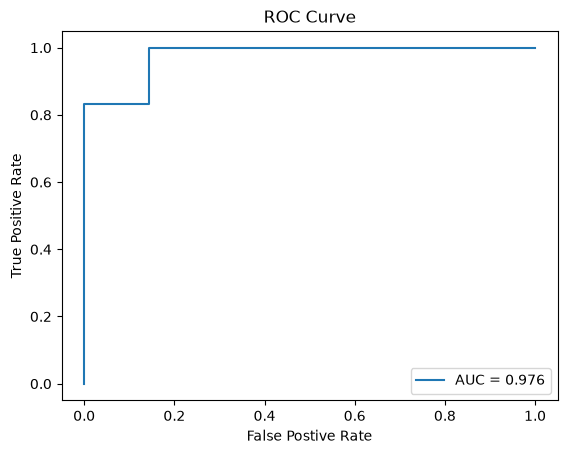

In [39]:
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")

plt.xlabel("False Postive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

In [40]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

In [41]:
from sklearn.pipeline import Pipeline

In [44]:
model_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression())
])

In [46]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)   

In [50]:
cv_scores = cross_val_score(
    model_pipeline,
    X,
    y,
    cv=cv
)

In [51]:
print(cv_scores)

[0.92307692 0.76923077 0.69230769 0.84615385 0.61538462]


In [55]:
cv_mean = cv_scores.mean()
cv_std = cv_scores.std()

print("Mean CV accuracy:", cv_mean)
print("CV standard deviation:", cv_std)

Mean CV accuracy: 0.7692307692307694
CV standard deviation: 0.10878565864408424


In [56]:
logistic_results = {
    "model": "Logistic Regression",
    "test_accuracy": accuracy,
    "roc_auc": auc,
    "cv_mean_accuracy": cv_mean,
    "cv_std_accuracy": cv_std
}

In [57]:
logistic_results_df = pd.DataFrame([logistic_results])

logistic_results_df

,model,test_accuracy,roc_auc,cv_mean_accuracy,cv_std_accuracy
0,Logistic Regression,0.846154,0.97619,0.769231,0.108786


In [58]:
logistic_results_df.to_csv(
    "../data/logistic_regression_results.csv",
    index=False
)

In [59]:
results_path = "../data/logistic_regression_results.csv"

print(pd.io.common.file_exists(results_path))

True


In [69]:
print(model.classes_)
print(model.coef_)

['A' 'C']
[[ 0.16401859 -1.4495823   0.59445129  0.38444437 -0.06974579]]


In [70]:
coefficients = pd.DataFrame({
    "Feature": ["Delta", "Theta", "Alpha", "Beta", "Gamma"],
    "Coefficient": model.coef_[0]
})

coefficients

,Feature,Coefficient
0,Delta,0.164019
1,Theta,-1.449582
2,Alpha,0.594451
3,Beta,0.384444
4,Gamma,-0.069746


In [90]:
from pathlib import Path

Path("../figures/logistic_regression").mkdir(
    parents=True,
    exist_ok=True
)

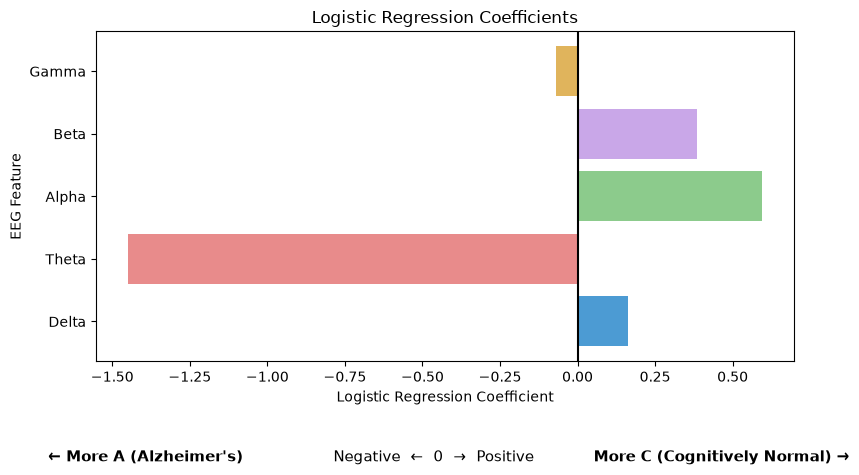

In [91]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))

plt.barh(
    coefficients["Feature"],
    coefficients["Coefficient"],
    color=["#4C9BD3", "#E88B8B", "#8CCB8C", "#C9A7E8", "#E0B45C"]
)

plt.axvline(0, color="black", linewidth=1.5)

plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("EEG Feature")
plt.title("Logistic Regression Coefficients")

plt.figtext(
    0.18, 0.02,
    "← More A (Alzheimer's)",
    ha="center",
    fontsize=11,
    fontweight="bold"
)

plt.figtext(
    0.50, 0.02,
    "Negative  ←  0  →  Positive",
    ha="center",
    fontsize=11
)

plt.figtext(
    0.82, 0.02,
    "More C (Cognitively Normal) →",
    ha="center",
    fontsize=11,
    fontweight="bold"
)

plt.subplots_adjust(bottom=0.22)

plt.savefig(
    "../figures/logistic_regression/logistic_coefficients.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

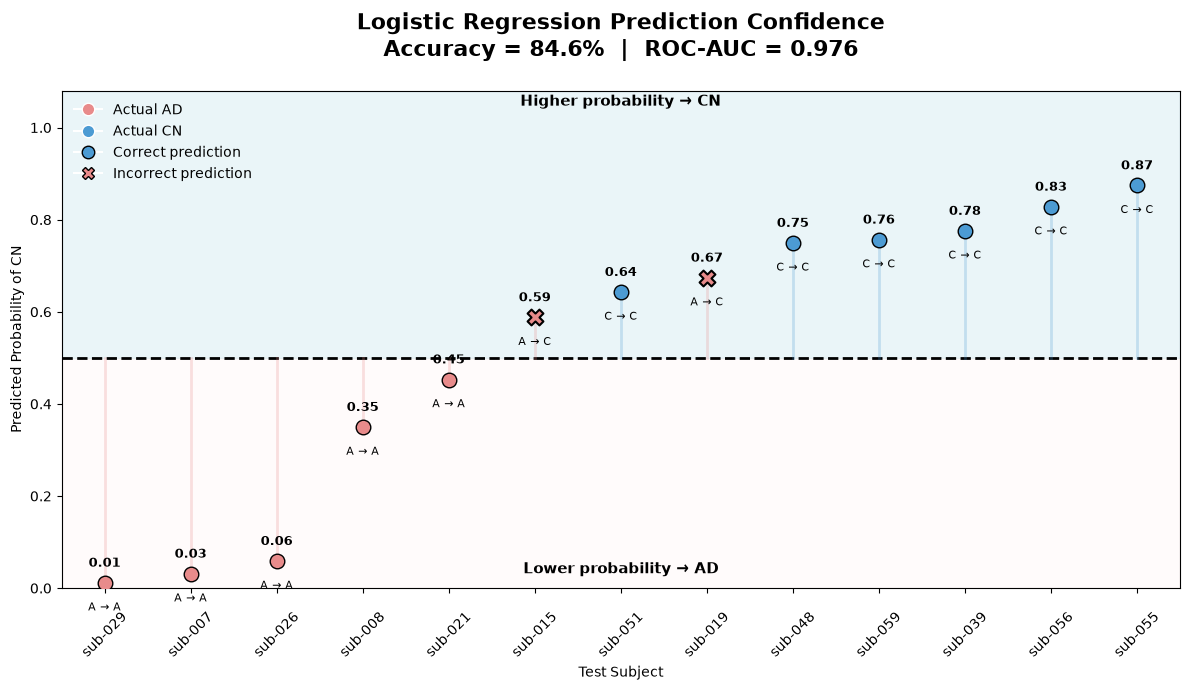

In [93]:
import matplotlib.pyplot as plt
import numpy as np

y_pred_from_prob = np.where(y_prob_c >= 0.5, "C", "A")

test_subjects = df.loc[y_test.index, "subject"].to_numpy()

order = np.argsort(y_prob_c)

probabilities = y_prob_c[order]
actual_groups = y_test.to_numpy()[order]
predicted_groups = y_pred_from_prob[order]
subject_ids = test_subjects[order]

plt.figure(figsize=(12, 7))

plt.axhspan(
    0.5,
    1.08,
    color="lightblue",
    alpha=0.25
)

plt.axhspan(
    0,
    0.5,
    color="mistyrose",
    alpha=0.12
)

plt.axhline(
    0.5,
    color="black",
    linestyle="--",
    linewidth=2,
    label="Decision threshold = 0.5"
)

for i in range(len(probabilities)):

    probability = probabilities[i]
    actual = actual_groups[i]
    predicted = predicted_groups[i]

    if actual == "A":
        point_color = "#E88B8B"
    else:
        point_color = "#4C9BD3"

    correct = actual == predicted

    plt.plot(
        [i + 1, i + 1],
        [0.5, probability],
        color=point_color,
        alpha=0.25,
        linewidth=2
    )

    if correct:
        plt.scatter(
            i + 1,
            probability,
            s=110,
            color=point_color,
            edgecolors="black",
            linewidths=1,
            marker="o",
            zorder=3
        )
    else:
        plt.scatter(
            i + 1,
            probability,
            s=130,
            color=point_color,
            edgecolors="black",
            linewidths=1.5,
            marker="X",
            zorder=4
        )

    plt.text(
        i + 1,
        probability + 0.035,
        f"{probability:.2f}",
        ha="center",
        fontsize=9,
        fontweight="bold"
    )

    plt.text(
        i + 1,
        probability - 0.06,
        f"{actual} → {predicted}",
        ha="center",
        fontsize=8
    )

plt.xticks(
    range(1, len(subject_ids) + 1),
    subject_ids,
    rotation=45
)

plt.tick_params(axis="x", pad=12)

plt.subplots_adjust(bottom=0.3)

plt.xlabel("Test Subject")
plt.ylabel("Predicted Probability of CN")

plt.title(
    f"Logistic Regression Prediction Confidence\n"
    f"Accuracy = {accuracy:.1%}  |  ROC-AUC = {auc:.3f}",
    fontsize=16,
    fontweight="bold",
pad=25
)

plt.text(
    0.5,
    0.97,
    "Higher probability → CN",
    transform=plt.gca().transAxes,
    ha="center",
    fontsize=11,
    fontweight="bold"
)

plt.text(
    0.5,
    0.03,
    "Lower probability → AD",
    transform=plt.gca().transAxes,
    ha="center",
    fontsize=11,
    fontweight="bold"
)

correct_legend = plt.Line2D(
    [0],
    [0],
    marker="o",
    color="w",
    markerfacecolor="#4C9BD3",
    markeredgecolor="black",
    markersize=9,
    label="Correct prediction"
)

wrong_legend = plt.Line2D(
    [0],
    [0],
    marker="X",
    color="w",
    markerfacecolor="#E88B8B",
    markeredgecolor="black",
    markersize=9,
    label="Incorrect prediction"
)

actual_ad = plt.Line2D(
    [0],
    [0],
    marker="o",
    color="w",
    markerfacecolor="#E88B8B",
    markersize=9,
    label="Actual AD"
)

actual_cn = plt.Line2D(
    [0],
    [0],
    marker="o",
    color="w",
    markerfacecolor="#4C9BD3",
    markersize=9,
    label="Actual CN"
)

plt.legend(
    handles=[
        actual_ad,
        actual_cn,
        correct_legend,
        wrong_legend
    ],
    loc="upper left",
    frameon=False
)

plt.xlim(0.5, len(subject_ids) + 0.5)
plt.ylim(0, 1.08)

plt.grid(False)

plt.tight_layout()

plt.savefig(
    "../figures/logistic_regression/prediction_confidence.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

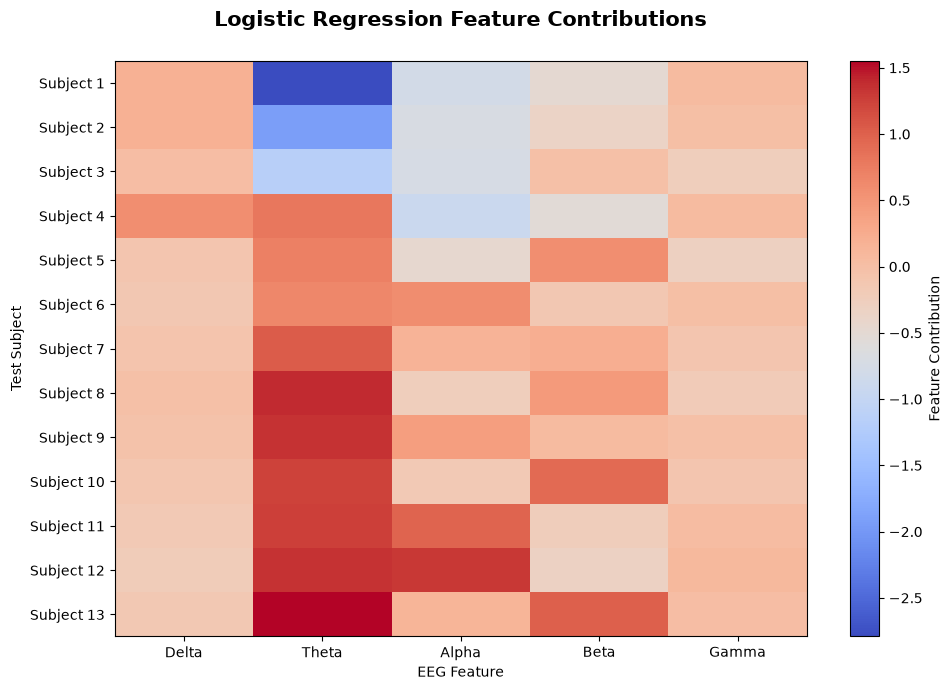

In [94]:
import matplotlib.pyplot as plt
import numpy as np

contributions = X_test_scaled * model.coef_[0]

features = ["Delta", "Theta", "Alpha", "Beta", "Gamma"]

order = np.argsort(y_prob_c)

contributions_sorted = contributions[order]

plt.figure(figsize=(10, 7))

plt.imshow(
    contributions_sorted,
    aspect="auto",
    cmap="coolwarm"
)

plt.colorbar(label="Feature Contribution")

plt.xticks(
    range(len(features)),
    features
)

plt.yticks(
    range(len(order)),
    [f"Subject {i+1}" for i in range(len(order))]
)

plt.xlabel("EEG Feature")
plt.ylabel("Test Subject")
plt.title(
    "Logistic Regression Feature Contributions",
    fontsize=15,
    fontweight="bold",
    pad=25
)

plt.tight_layout()


plt.savefig(
    "../figures/logistic_regression/feature_contributions.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Logistic Regression — Detailed Summary and Experimental Record

## 1. Purpose

This notebook represents the first machine-learning stage of the project.

The objective is to investigate whether subject-level relative EEG spectral-power features can be used to distinguish **Alzheimer's disease (AD)** from **cognitively normal (CN)** participants.

The **Frontotemporal dementia (FTD)** group was excluded from this initial binary-classification experiment so that the first model addresses a two-class problem:

**Alzheimer's disease (AD) vs Cognitively normal (CN)**

This stage is intended as an initial machine-learning experiment and does not represent a final diagnostic or clinical model.

---

## 2. Input Dataset

The machine-learning analysis uses the subject-level feature dataset generated in:

`02_all_subjects_features.ipynb`

The original dataset contains:

- **36 Alzheimer's disease (AD)**
- **29 Cognitively normal (CN)**
- **23 Frontotemporal dementia (FTD)**
- **88 participants in total**

**Relative EEG Power Distribution Vizualization:** The distribution of the five relative EEG spectral-power features was visualized separately for Alzheimer's disease (AD) and cognitively normal (CN) participants. The boxplots summarize the distribution of each frequency band, while the individual points represent the values of individual participants and the open circles indicate the group means. This visualization provides an exploratory comparison of the EEG feature distributions between the two groups and helps illustrate the characteristics of the features subsequently used as inputs to the Logistic Regression model.

For this binary-classification experiment, only the AD and CN groups were retained.

### Dataset used for Logistic Regression

- **AD:** 36 participants
- **CN:** 29 participants
- **Total:** 65 participants

Each participant is represented by five EEG spectral features:

- Delta relative power
- Theta relative power
- Alpha relative power
- Beta relative power
- Gamma relative power

The feature dataset is subject-level, meaning:

**1 row = 1 participant**

This prevents individual EEG epochs from being treated as separate independent samples during the machine-learning stage.

---

## 3. Features and Target

The machine-learning input matrix was defined as:

**X = Delta, Theta, Alpha, Beta, Gamma**

The classification target was:

**y = Diagnostic group**

where:

- `A` = Alzheimer's disease
- `C` = Cognitively normal

Thus:

**X → EEG spectral features**

**y → diagnostic class**

The following variables were not used as input features for the EEG-only Logistic Regression model:

- Subject identifier
- Diagnostic group
- Age
- MMSE

The model therefore attempts to classify the participant using only the five relative EEG spectral-power features.

---

## 4. Train-Test Split

The 65 AD/CN participants were divided into:

- **80% training data**
- **20% testing data**

This produced:

- **52 training participants**
- **13 testing participants**

A stratified split was used so that the proportion of AD and CN participants remained approximately balanced between the training and testing sets.

A fixed random state of `42` was used to make the split reproducible.

The test set was held out during the initial model-fitting stage and used afterward to evaluate the trained Logistic Regression model.

---

## 5. Feature Scaling

The five EEG features were standardized using Scikit-learn's `StandardScaler`.

The scaler was:

1. Fitted using the training data.
2. Used to transform the training data.
3. Used to transform the test data using the same learned scaling parameters.

Standardization places the numerical features on a comparable scale.

This is particularly useful for Logistic Regression because the model coefficients are affected by feature scale.

Importantly, the scaler was **not fitted using the test set**, preventing test-set information from being incorporated into the scaling parameters.

---

## 6. Logistic Regression

Logistic Regression was selected as the first machine-learning classifier.

Although its name contains the word "regression," Logistic Regression is commonly used for **binary classification**.

The model learns a mathematical relationship between the five EEG features and the two diagnostic classes.

The fitted model classes were:

`['A', 'C']`

Therefore:

- `A` represents Alzheimer's disease
- `C` represents cognitively normal

Because `C` is the second class, the coefficient direction can be interpreted as:

- **Positive coefficient → pushes the model toward C**
- **Negative coefficient → pushes the model toward A**

The features were standardized before training, allowing their coefficient magnitudes to be compared within this fitted model.

---

## 7. Model Training

The Logistic Regression model was trained using the scaled training data:

**Training input:** `X_train_scaled`

**Training target:** `y_train`

The model learned its classification relationship from the 52 training participants.

The held-out 13 test participants were not used to fit the model.

The trained model was then used to generate:

- Predicted classes
- Class probabilities

for the unseen test participants.

---

## 8. Test-Set Predictions

The trained Logistic Regression model was used to predict the diagnostic class of the 13 held-out test participants.

The prediction output contained either:

`A`

or:

`C`

for each test participant.

The model predictions were compared against the true labels in `y_test`.

The actual and predicted classifications were:

**Actual:**

`A C C A C A C A A C A C A`

**Predicted:**

`A C C C C A C A A C A C C`

The model therefore produced:

- **11 correct predictions**
- **2 incorrect predictions**

out of:

- **13 total test participants**

---

## 9. Test-Set Accuracy

The initial test-set accuracy was:

**84.6%**

This was calculated as:

**11 correct predictions / 13 total predictions**

Therefore:

`11 / 13 = 0.8462`

or approximately:

**84.6% accuracy**

This result describes the performance on this particular held-out test split and should not be interpreted as the final performance of the model.

---

## 10. Confusion Matrix

The confusion matrix was:

| | Predicted AD | Predicted CN |
|---|---:|---:|
| **Actual AD** | 5 | 2 |
| **Actual CN** | 0 | 6 |

This can be interpreted as:

- **5 AD participants** → correctly classified as AD
- **2 AD participants** → incorrectly classified as CN
- **0 CN participants** → incorrectly classified as AD
- **6 CN participants** → correctly classified as CN

Therefore:

**Correct = 5 + 6 = 11**

**Incorrect = 2 + 0 = 2**

**Total = 13**

The confusion matrix provides more detail than accuracy alone because it shows **which type of classification error occurred**.

---

## 11. Precision, Recall, and F1-Score

The classification report provided precision, recall, F1-score, and support for each class.

| Class | Precision | Recall | F1-score | Support |
|---|---:|---:|---:|---:|
| AD | 1.00 | 0.71 | 0.83 | 7 |
| CN | 0.75 | 1.00 | 0.86 | 6 |

### AD

**Precision = 1.00**

Every participant predicted as AD was actually AD in this test set.

**Recall = 0.71**

Of the 7 participants who were actually AD, the model correctly identified 5.

**F1-score = 0.83**

This combines precision and recall into a single measure.

**Support = 7**

There were 7 actual AD participants in the test set.

### CN

**Precision = 0.75**

Of the participants predicted as CN, 75% were actually CN.

**Recall = 1.00**

All 6 actual CN participants were correctly identified.

**F1-score = 0.86**

This combines CN precision and recall.

**Support = 6**

There were 6 actual CN participants in the test set.

---

## 12. ROC-AUC Analysis

The Logistic Regression model also generated class probabilities using:

`predict_proba()`

Instead of producing only `A` or `C`, the model provides probabilities for both classes.

For each test participant, the output has the form:

`[A probability, C probability]`

The **C probability** was used as the positive-class score for the ROC analysis.

The ROC curve evaluates model performance across different probability thresholds rather than using only the default 0.5 threshold.

Conceptually:

**Different thresholds → different classification results → ROC points → ROC curve → area under curve**

The resulting:

**ROC-AUC = 0.976**

The ROC-AUC summarizes the ranking/discrimination ability of the model's predicted probabilities across thresholds.

The ROC-AUC should not be interpreted as 97.6% accuracy.

Because the test set contains only 13 participants, this result should be treated as an initial observation rather than a stable estimate of generalization performance.

---

## 13. Cross-Validation

Five-fold stratified cross-validation was performed using a Scikit-learn pipeline containing:

**StandardScaler → Logistic Regression**

The pipeline ensures that feature scaling is performed within the cross-validation workflow rather than fitting the scaler once on the complete dataset.

The five fold accuracy scores were:

| Fold | Accuracy |
|---|---:|
| Fold 1 | 92.3% |
| Fold 2 | 76.9% |
| Fold 3 | 69.2% |
| Fold 4 | 84.6% |
| Fold 5 | 61.5% |

The mean cross-validation accuracy was:

**76.9%**

The standard deviation was:

**10.9%**

The variation between folds indicates that model performance changes depending on which participants are included in each validation fold.

### Important methodological note

The initial cross-validation was performed using the complete 65-participant AD/CN dataset after the initial train-test split.

Therefore, the held-out 13-participant test set was also included in this cross-validation calculation.

For the final model-comparison stage, the validation protocol should be refined so that:

- the test set remains completely untouched until final evaluation;
- cross-validation is used only within the training data;
- model selection and parameter decisions are made without using the final test set.

This will provide a cleaner and more rigorous estimate of model generalization.

---

## 14. Model Coefficients

The fitted Logistic Regression coefficients were:

| EEG Feature | Coefficient |
|---|---:|
| Delta | 0.164 |
| Theta | -1.450 |
| Alpha | 0.594 |
| Beta | 0.384 |
| Gamma | -0.070 |

Because the model classes were:

`['A', 'C']`

the coefficient direction is interpreted as:

**Positive → movement toward CN**

**Negative → movement toward AD**

Within this fitted model:

- **Theta** had the largest negative coefficient.
- **Alpha** had the largest positive coefficient.
- **Beta** also had a positive coefficient.
- **Delta** had a smaller positive coefficient.
- **Gamma** had a small negative coefficient.

Because the features were standardized, the coefficient magnitudes can be compared within this model.

These coefficients represent relationships learned by the classifier and should **not** be interpreted as evidence of causation or as independent biological effects of the frequency bands.

---

## 15. Model Prediction Confidence

The model's predicted probabilities were examined for the 13 held-out test participants.

The prediction-confidence analysis visualizes:

- Actual diagnostic group
- Predicted probability of CN
- The 0.5 decision threshold
- Correct predictions
- Incorrect predictions
- Individual test participants

The default decision rule can be represented as:

**CN probability ≥ 0.5 → predicted CN**

**CN probability < 0.5 → predicted AD**

The visualization highlights the two AD participants whose predicted CN probability exceeded 0.5 and were therefore incorrectly classified as CN.

This provides a subject-level view of how confidently the Logistic Regression model made its predictions.

---

## 16. Model Visualizations

The notebook contains several model-focused visualizations.

### 🧠 Logistic Regression Coefficient Plot

Visualizes the learned coefficient for each EEG spectral feature.

The sign of each coefficient indicates the direction of the model's learned relationship:

**Negative → AD**

**Positive → CN**

The magnitude indicates the strength of the feature's contribution within the standardized Logistic Regression model.

### 🎯 Confusion Matrix

Shows the number of correct and incorrect predictions for AD and CN.

This provides a direct view of classification errors that cannot be seen from accuracy alone.

### 📈 ROC Curve

Shows the relationship between:

- True-positive rate
- False-positive rate

across different probability thresholds.

The corresponding ROC-AUC was:

**0.976**

### 🔍 Prediction Confidence

Shows the predicted CN probability for each held-out test participant, together with the 0.5 decision threshold.

The visualization also distinguishes correct and incorrect predictions.

### 🧬 Feature-Contribution Heatmap

Shows the contribution of each standardized EEG feature to the Logistic Regression decision for individual test participants.

This provides a subject-level interpretation of how the model's learned coefficients interact with the observed EEG features.

Together, these visualizations provide complementary views of:

**model performance → model interpretation → prediction confidence → subject-level feature contributions**

---

## 17. Saved Figures

The model visualizations are stored as high-resolution PNG files in:

`figures/logistic_regression/`

Currently saved figures include:

- `prediction_confidence.png`
- `logistic_coefficients.png`
- `feature_contributions.png`

These figures are intended for reuse in the project documentation and GitHub README.

Additional model figures can be saved to the same directory as the analysis develops.

---

## 18. Interpretation of the Initial Model

The initial Logistic Regression experiment demonstrates that the five subject-level EEG spectral features contain information that the classifier can use to separate AD and CN participants in this particular dataset split.

The held-out test split produced:

**84.6% accuracy**

and:

**ROC-AUC = 0.976**

However, the five-fold cross-validation produced:

**76.9% mean accuracy ± 10.9% standard deviation**

The difference between the single test-set accuracy and the cross-validation mean illustrates the variability that can arise from using a relatively small number of participants.

The current results should therefore be interpreted as **initial model-development findings**, not as evidence of clinical diagnostic performance.

---

## 19. Limitations of the Initial Model

Several limitations should be considered.

### Small sample size

The first binary experiment contains only:

**65 participants**

and the held-out test set contains:

**13 participants**

Therefore, individual performance metrics can be sensitive to the particular participants included in the train-test split.

### Binary classification only

FTD was excluded from this first experiment.

The current model therefore does not address the more complex three-group problem of:

**AD vs FTD vs CN**

### Validation protocol

The initial cross-validation was performed on all 65 AD/CN participants after creating the initial train-test split.

For final model comparison, a more rigorous validation structure will keep the final test set untouched while model selection and cross-validation are performed only on the training data.

### Feature representation

The current model uses five scalp-averaged spectral features.

This representation intentionally reduces the spatial information contained in the 19 EEG channels.

More detailed regional or channel-level feature representations may be investigated later.

### Model scope

Only Logistic Regression has been evaluated so far.

Additional models are required before drawing conclusions about comparative model performance.

---

## 20. Reproducibility

The Logistic Regression workflow uses fixed random states where applicable.

The train-test split uses:

`random_state = 42`

The cross-validation procedure also uses:

`random_state = 42`

The feature scaling and Logistic Regression steps were combined into a Scikit-learn pipeline for cross-validation.

The analysis is implemented using:

- Python
- Pandas
- NumPy
- Matplotlib
- Scikit-learn

The underlying EEG dataset is not committed to the GitHub repository.

---

## 21. Next Step

The next stage will implement additional machine-learning models using the same subject-level EEG feature dataset.

Planned models include:

- **Support Vector Machine (SVM)**
- **Random Forest**

Each model will be developed and evaluated separately.

The same overall evaluation framework will be applied so that the models can later be compared using consistent metrics and validation procedures.

The final model-comparison stage will examine:

- Test-set performance
- Cross-validation performance
- Precision
- Recall
- F1-score
- ROC-AUC
- Confusion matrices
- Model interpretability

The final comparison will use a properly defined subject-level validation strategy with the held-out test set kept separate from model selection.

---

## 22. Current Status

**Logistic Regression analysis completed — initial model.**

The first machine-learning workflow has been successfully implemented, evaluated, visualized, and documented.

The next major stage of the project is:

**SVM → Random Forest → Model Comparison**